<a href="https://colab.research.google.com/github/umiSirya/netflix_content_analysis/blob/main/netflix_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
df = pd.read_csv('/content/netflix_titles.csv')
df.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


# **EDA and Cleaning**

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB



### Dataset Overview

This dataset contains information about **8,807 movies and TV shows** available on Netflix. Each row represents a single title, and the dataset includes details such as the title's type, cast, director, country of origin, release year, rating, duration, genre, and description.

### Dataset Size

* **Rows:** 8,807 (titles)
* **Columns:** 12 (features)

### Features Description

| Feature        | Description                                                                                  |
| -------------- | -------------------------------------------------------------------------------------------- |
| `show_id`      | Unique identifier assigned to each Netflix title.                                            |
| `type`         | Indicates whether the title is a Movie or TV Show.                                           |
| `title`        | Name of the movie or TV show.                                                                |
| `director`     | Director(s) of the title. Contains missing values where director information is unavailable. |
| `cast`         | Main actors and actresses featured in the title.                                             |
| `country`      | Country or countries where the title was produced.                                           |
| `date_added`   | Date the title was added to Netflix.                                                         |
| `release_year` | Year the title was originally released.                                                      |
| `rating`       | Content rating (e.g., TV-MA, PG-13, TV-14).                                                  |
| `duration`     | Length of the movie (in minutes) or number of seasons for TV shows.                          |
| `listed_in`    | Genre or category of the title.                                                              |
| `description`  | Brief summary or synopsis of the title.                                                      |

### Data Types

**Numerical Feature (1):**

* `release_year`

**Categorical/Text Features (11):**

* `show_id`
* `type`
* `title`
* `director`
* `cast`
* `country`
* `date_added`
* `rating`
* `duration`
* `listed_in`
* `description`

### Missing Values

The dataset contains missing values in several columns:

* `director`: 2,634 missing values
* `cast`: 825 missing values
* `country`: 831 missing values
* `date_added`: 10 missing values
* `rating`: 4 missing values
* `duration`: 3 missing values

### Brief Summary

This dataset is useful for exploring Netflix's content library, analyzing trends in movie and TV show production, studying content ratings and genres, identifying top-producing countries, and understanding how Netflix's catalog has evolved over time. It contains predominantly categorical and text-based data, with `release_year` being the primary numerical feature available for quantitative analysis.


In [33]:
# missing values
missing= df.isnull().sum()
print('The missing values are in the columns:\n', missing)

The missing values are in the columns:
 show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [34]:
# Filling the missing data
df['director'] = df['director'].fillna('Unknown')

df['cast'] = df['cast'].fillna('Unknown')

df['date_added'] = df['date_added'].fillna('Unknown')

df['country'] = df['country'].fillna(df['country'].mode()[0])

df['rating'] = df['rating'].fillna(df['rating'].mode()[0])

df['duration'] = df['duration'].fillna('Unknown')

# **Brief Description**

Missing values were handled to ensure the dataset is complete and suitable for analysis. For categorical text columns such as director, cast, date_added, and duration, missing values were filled with "Unknown" to retain all records while clearly marking unavailable information. For country and rating, missing values were replaced with the most frequent value (mode) because these are categorical features where the most common entry provides a reasonable estimate. This approach helps maintain data integrity without losing important rows from the dataset.

In [35]:
# duplicate rows - there are no duplicate rows

duplicate = df.duplicated().sum()
print('The duplicate rows are:', duplicate)

The duplicate rows are: 0


In [36]:
# Column names
df.columns = df.columns.str.lower().str.replace(' ', '_')

# Date conversion
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Removing extra spaces
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

# Text formatting
df['title'] = df['title'].str.lower()
df['director'] = df['director'].str.lower()
df['cast'] = df['cast'].str.lower()
df['country'] = df['country'].str.lower()
df['listed_in'] = df['listed_in'].str.lower()
df['description'] = df['description'].str.lower()

In [37]:
df.describe()

,date_added,release_year
count,8709,8807.000000
mean,2019-05-23 01:45:29.452290816,2014.180198
min,2008-01-01 00:00:00,1925.000000
25%,2018-04-20 00:00:00,2013.000000
50%,2019-07-12 00:00:00,2017.000000
75%,2020-08-26 00:00:00,2019.000000
max,2021-09-25 00:00:00,2021.000000
std,NaN,8.819312


In [38]:
# handling the 2 different dtypes in the duration column

#  Ensure column is string type
df['duration'] = df['duration'].astype(str)

# Extract numeric value (e.g., 90 from "90 min")
df['duration_value'] = df['duration'].str.extract('(\d+)').astype(float)

#  Extract text part (min / Seasons)
df['duration_type'] = df['duration'].str.extract('([A-Za-z]+)')

# Check result
print(df[['duration', 'duration_value', 'duration_type']].head())

    duration  duration_value duration_type
0     90 min            90.0           min
1  2 Seasons             2.0       Seasons
2   1 Season             1.0        Season
3   1 Season             1.0        Season
4  2 Seasons             2.0       Seasons


<>:7: SyntaxWarning: invalid escape sequence '\d'
<>:7: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_7084/1084373345.py:7: SyntaxWarning: invalid escape sequence '\d'
  df['duration_value'] = df['duration'].str.extract('(\d+)').astype(float)


| Issue Found     | Action Taken                                                |
| --------------- | ----------------------------------------------------------- |
| Missing Values  | Filled using `"Unknown"` or mode values                     |
| Duplicates      | No duplicates found                                         |
| Invalid Entries | Handled using cleaning and format correction                |
| Standardization | Applied (text formatting, date conversion, column cleaning) |


# **Visualizations**

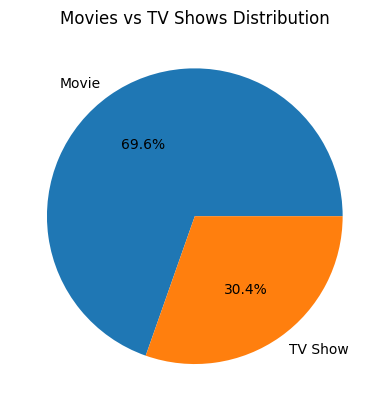

In [46]:
# Movies vs Tv shows

df['type'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Movies vs TV Shows Distribution')
plt.ylabel('')
plt.show()

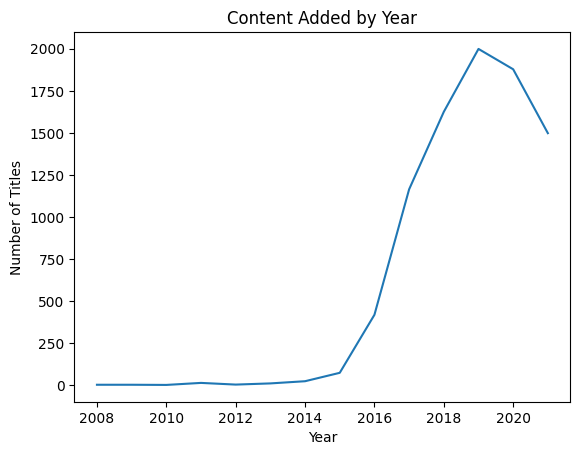

In [40]:
# Content added by year
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year

df['year_added'].value_counts().sort_index().plot(kind='line')

plt.title('Content Added by Year')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.show()

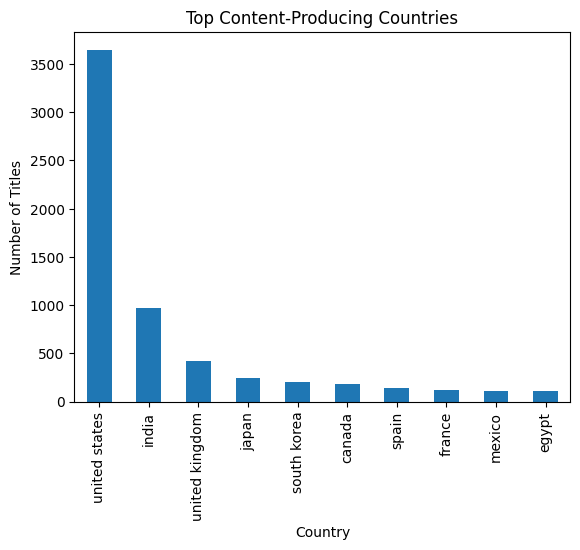

In [41]:
# Top Content producing countries
df['country'].value_counts().head(10).plot(kind='bar')

plt.title('Top Content-Producing Countries')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.show()

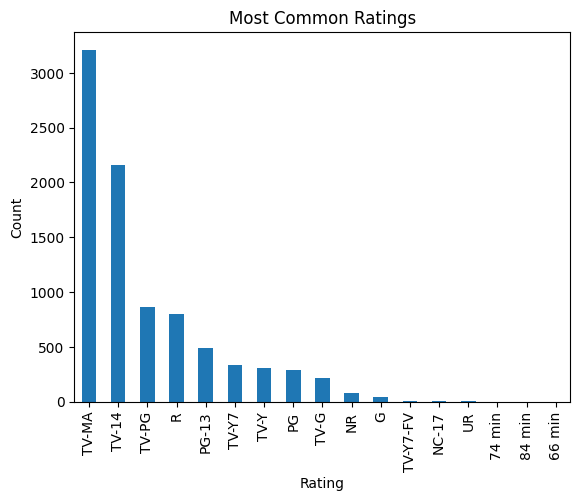

In [42]:
# Most Common rattings

df['rating'].value_counts().plot(kind='bar')

plt.title('Most Common Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

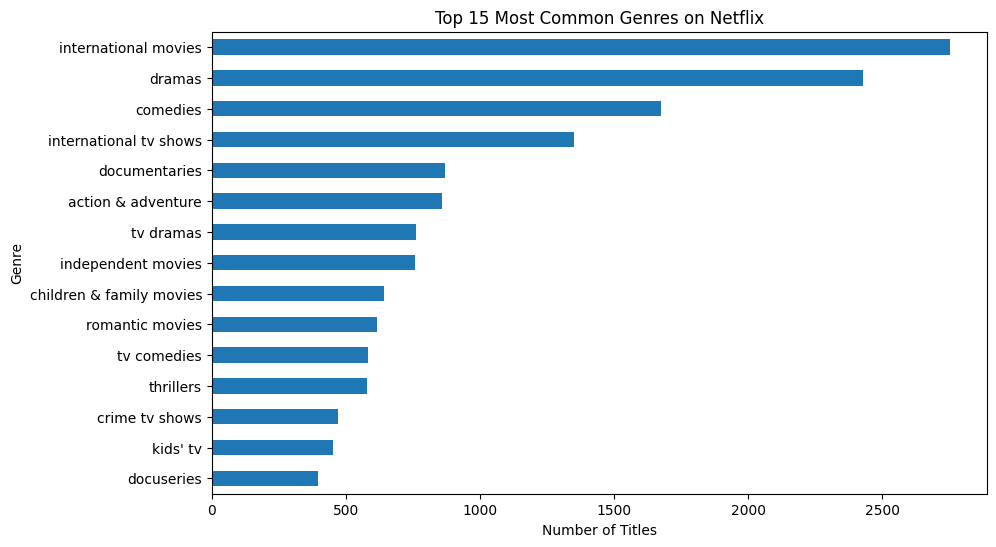

In [45]:
# Most common genres


# split genres properly
genres = df['listed_in'].str.split(', ').explode()

#  get top genres
top_genres = genres.value_counts().head(15)

# plot
plt.figure(figsize=(10,6))
top_genres.sort_values().plot(kind='barh')

plt.title('Top 15 Most Common Genres on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')

plt.show()